# Simulation Analysis

This file is to be used to analyse observable quantities of a simulation

In [37]:

import sys
from pathlib import Path

if sys.platform == "darwin":
    proj = "/Users/rileymcnamara/CODE/2025/silicokit/"
    sys.path.insert(0, proj)
else:
    proj = "C:/Users/riley.mcnamara/Documents/code/silicokit/"
    sys.path.insert(0, proj)

from src.growkit.PlotEngine.SimPlotter import SimPlotter
from src.growkit.PlotEngine.CellFieldPlotter import CellFieldPlotter
from src.growkit.Simulator import TumorGrowthSimulator

simulator = TumorGrowthSimulator(proj + "/configs/T_N.yaml")

simulation_data = simulator.load_simulation_data(proj + "/laboratory/saved_simulations/simulation_data.npz")

sim_plotter = SimPlotter(simulation_data)
cell_plotter = CellFieldPlotter(simulation_data, simulator=simulator)


Pre-compiling Numba functions...
Numba functions compiled successfully!
Loading simulation data from /Users/rileymcnamara/CODE/2025/silicokit//laboratory/saved_simulations/simulation_data.npz...
Loaded simulation data with 21 saved steps (using memory mapping: True)


## Radius Evolution

Calculating tumor radius evolution...
Calculating inhibited radius evolution...
Calculating necrotic radius evolution...
Calculating hypoxic radius evolution...


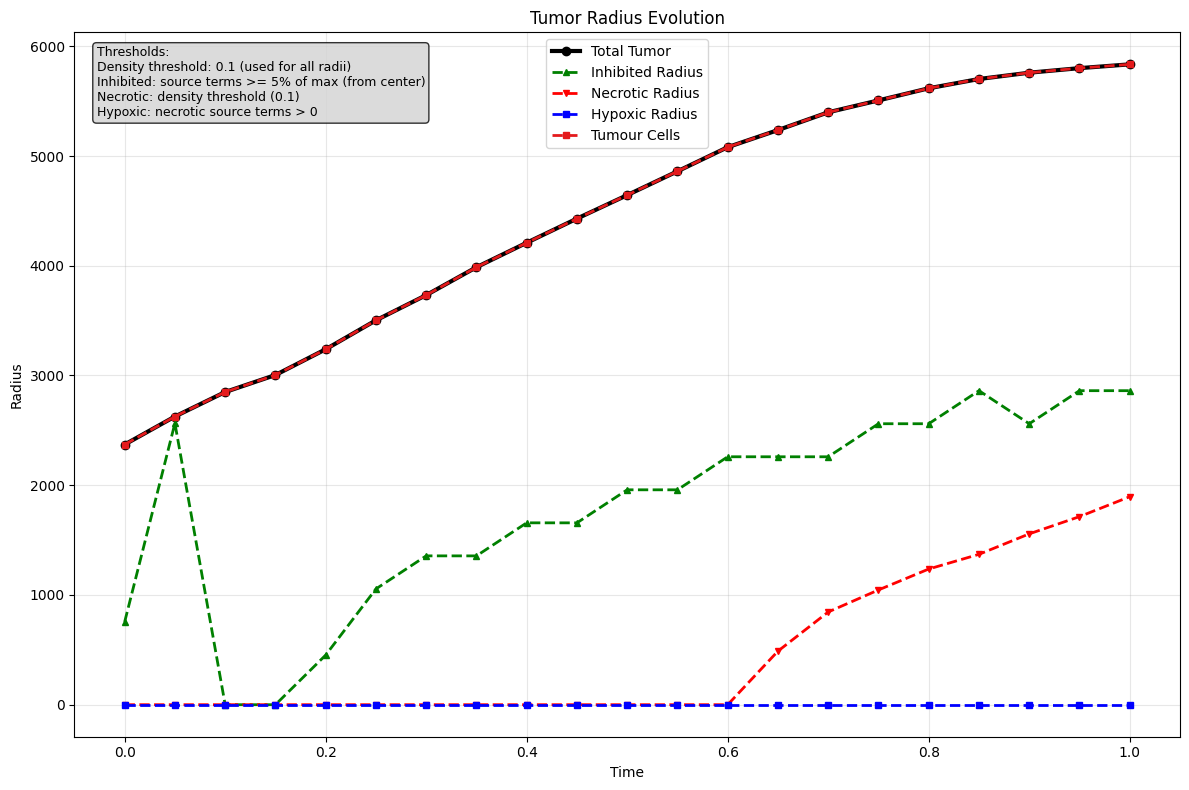

{'total_radii': [np.float64(2370.721278719846),
  np.float64(2626.0296518961213),
  np.float64(2849.291681250115),
  np.float64(3004.219694527065),
  np.float64(3238.8504168153545),
  np.float64(3502.575332070748),
  np.float64(3732.2122060390925),
  np.float64(3986.539698045854),
  np.float64(4209.573458355548),
  np.float64(4429.512084820335),
  np.float64(4643.5146863951395),
  np.float64(4860.549099238704),
  np.float64(5080.49600907887),
  np.float64(5236.2454701110455),
  np.float64(5398.265774022943),
  np.float64(5506.623306382033),
  np.float64(5617.103592496472),
  np.float64(5701.637314057119),
  np.float64(5759.082466900929),
  np.float64(5800.684991186275),
  np.float64(5835.193775716518)],
 'population_radii': {'Tumour Cells': [np.float64(2370.721278719846),
   np.float64(2626.0292169709237),
   np.float64(2849.2911136067733),
   np.float64(3004.219291540848),
   np.float64(3238.8511049298095),
   np.float64(3502.575077193776),
   np.float64(3732.2116734402),
   np.float6

In [46]:
sim_plotter.plot_tumor_radius_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), include_individual_populations=True, threshold=0.1, method='contour', growth_threshold=0.45)

In [39]:
#sim_plotter.plot_density_and_source_with_radii()

## Population Density Evolution

Calculating population density evolution...


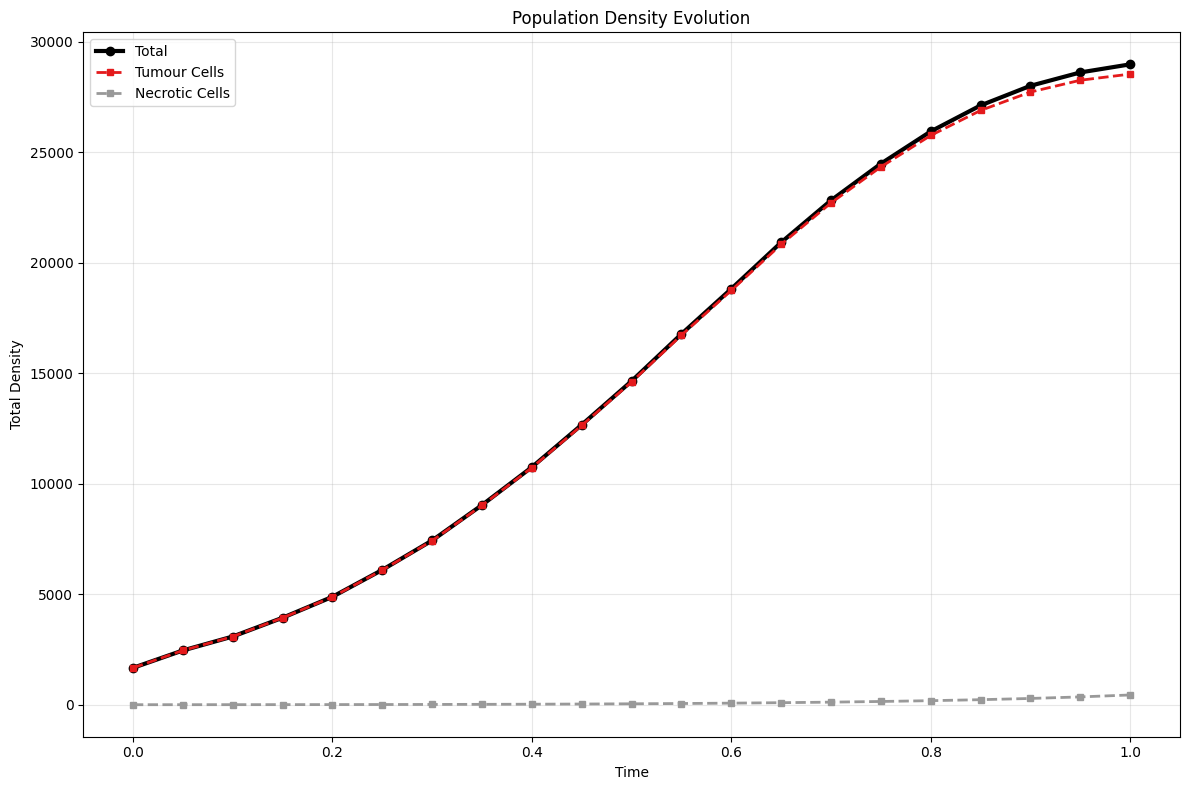

{'total_densities': [np.float32(1668.0345),
  np.float32(2455.2278),
  np.float32(3085.4946),
  np.float32(3934.6929),
  np.float32(4883.388),
  np.float32(6101.362),
  np.float32(7433.277),
  np.float32(9036.7),
  np.float32(10750.707),
  np.float32(12667.641),
  np.float32(14645.561),
  np.float32(16776.117),
  np.float32(18819.338),
  np.float32(20921.834),
  np.float32(22824.498),
  np.float32(24483.701),
  np.float32(25944.225),
  np.float32(27120.865),
  np.float32(28008.812),
  np.float32(28613.861),
  np.float32(28979.863)],
 'population_densities': {'Tumour Cells': [np.float32(1668.0345),
   np.float32(2454.3506),
   np.float32(3083.5137),
   np.float32(3931.242),
   np.float32(4877.9585),
   np.float32(6093.289),
   np.float32(7421.66),
   np.float32(9020.383),
   np.float32(10728.184),
   np.float32(12637.041),
   np.float32(14604.565),
   np.float32(16721.928),
   np.float32(18748.635),
   np.float32(20830.719),
   np.float32(22708.467),
   np.float32(24337.592),
   np.floa

In [40]:
sim_plotter.plot_population_density_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(12, 8), normalize_by_volume=False)

Plotting evolution for population: Tumour Cells (index: 0)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


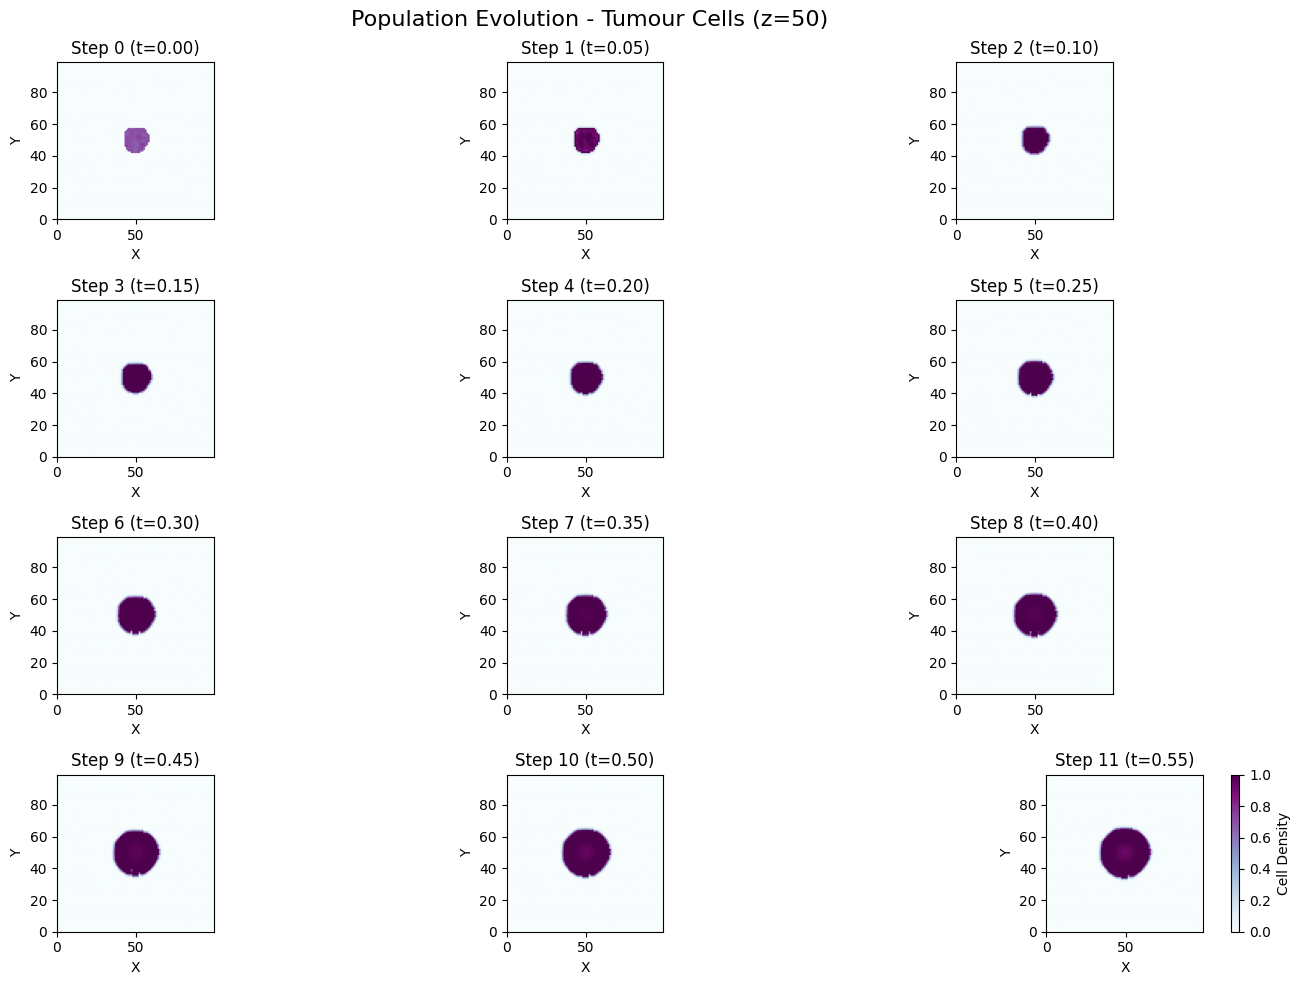

In [41]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Tumour Cells", cmap="BuPu", show_plot=True)

Plotting evolution for population: Necrotic Cells (index: 1)
Available population labels: ['Tumour Cells', 'Necrotic Cells']
Step indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


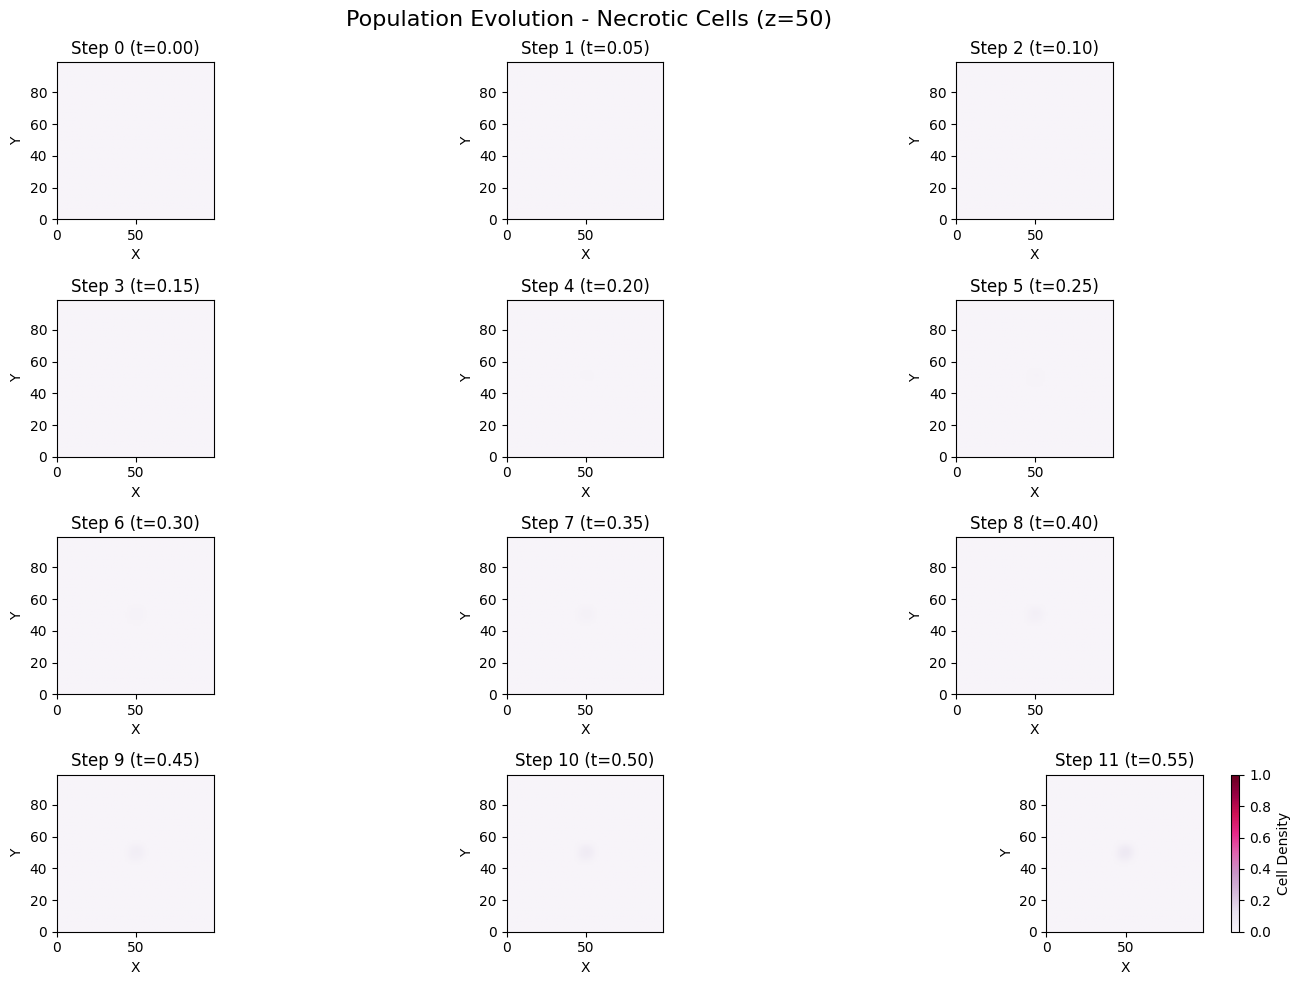

In [42]:
cell_plotter.plot_population_evolution_by_label(simulation_data, label="Necrotic Cells", cmap="PuRd", show_plot=True)

Creating nutrient field evolution plot...


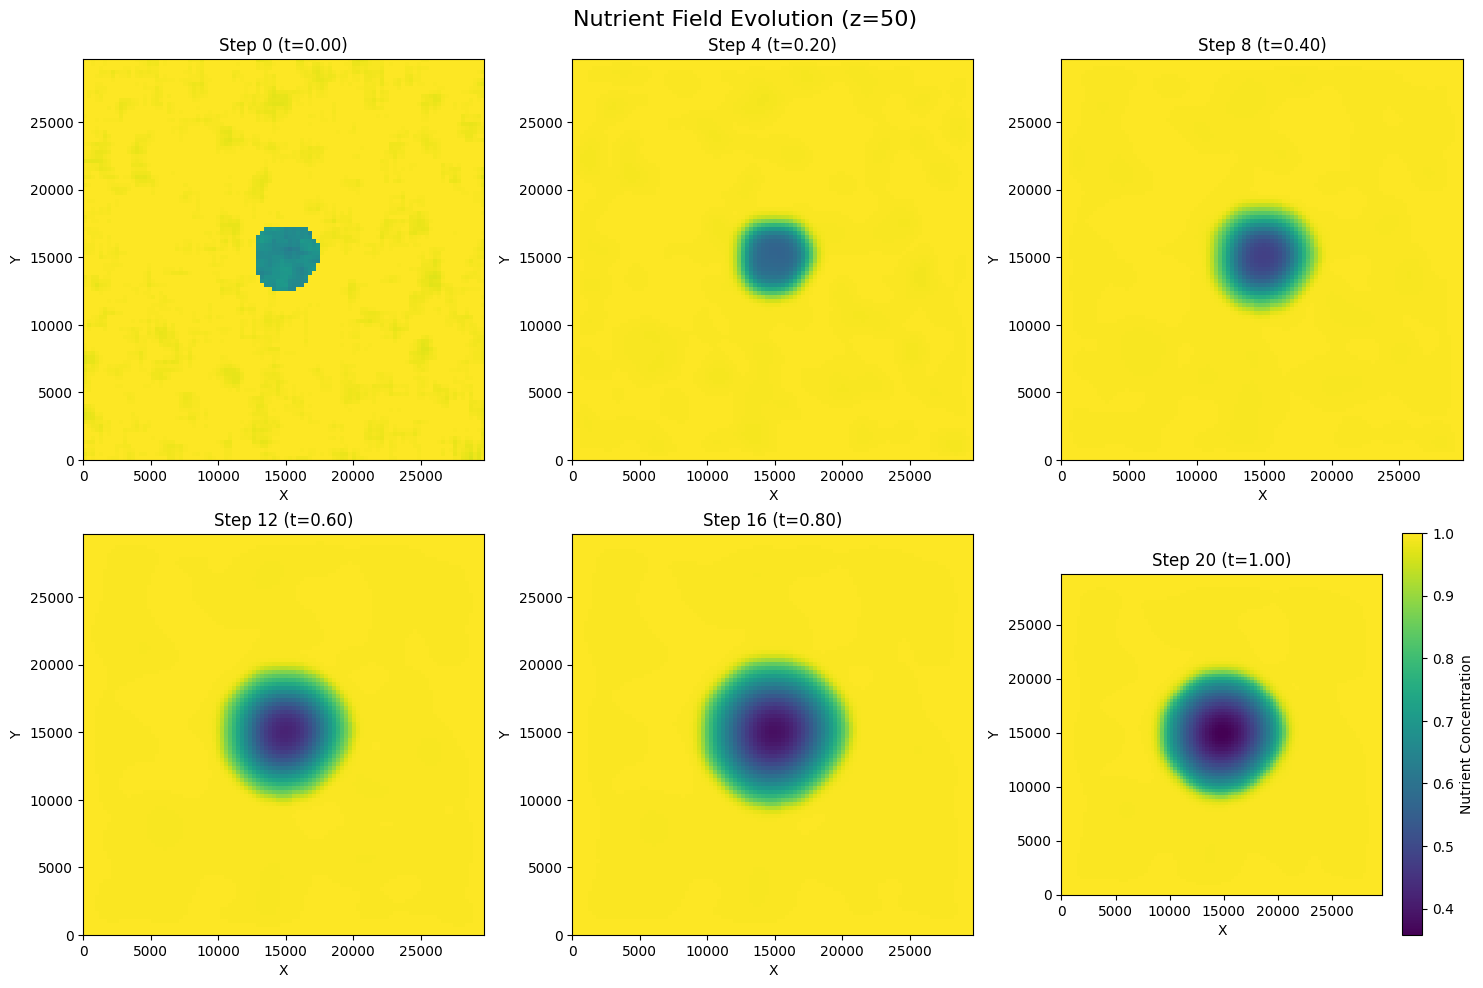

In [43]:
sim_plotter.plot_nutrient_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="viridis", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating source field evolution plot...


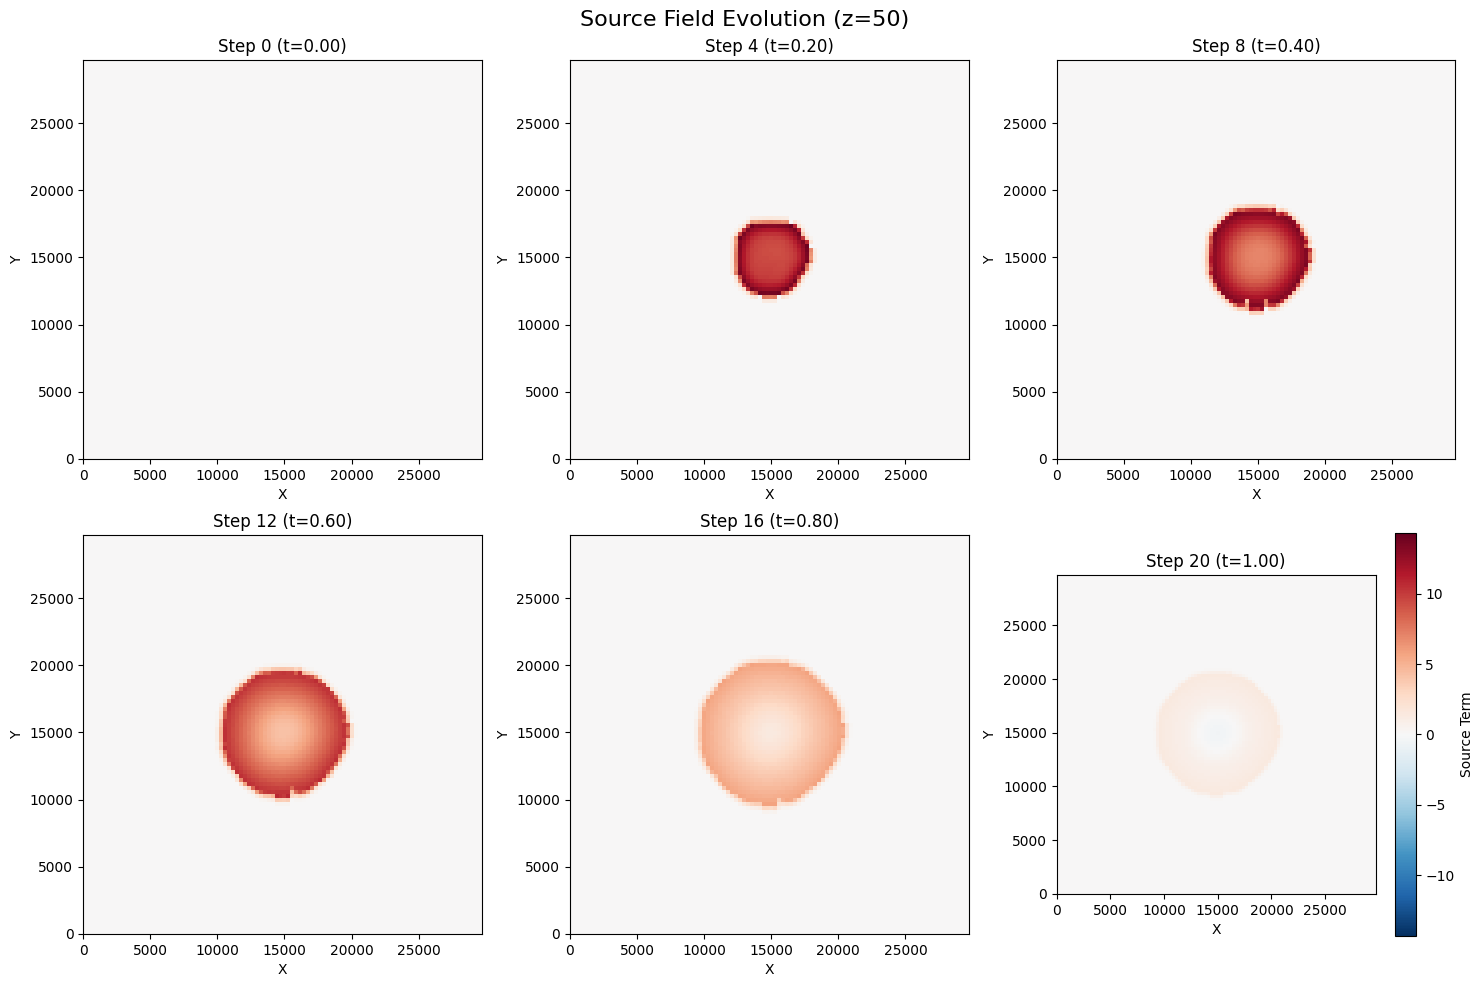

In [44]:
sim_plotter.plot_source_field_evolution(output_dir=None, save_plot=False, show_plot=True, figsize=(15, 10), z_slice=None, cmap="RdBu_r", add_tumor_contours=False, tumor_threshold=0.1, max_plots=6, include_statistics=False)

Creating custom source field plot...
Plotting source fields for populations: ['Necrotic Cells']


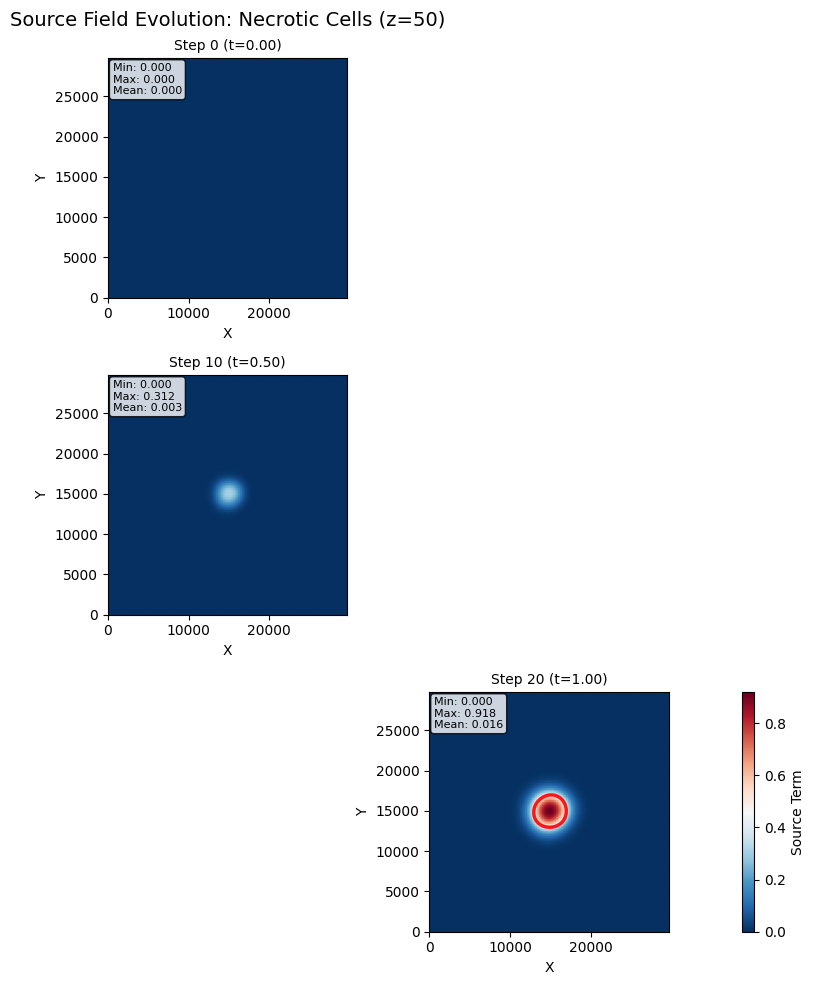

{'population_indices': [1],
 'population_labels': ['Necrotic Cells'],
 'plot_indices': array([ 0, 10, 20]),
 'z_slice': 50}

In [45]:
sim_plotter.plot_custom_source_fields(
    population_labels=['Necrotic Cells'],
    add_necrotic_boundary=True,
    max_plots=3
)